In [98]:
# !pip install pyreadstat
# !pip install scikeras tensorflow scikit-learn

In [99]:
# pip install --upgrade tensorflow

In [100]:
# import tensorflow as tf
# print("TensorFlow version:", tf.__version__)
# print("GPU available:", tf.config.list_physical_devices('GPU'))


In [101]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


In [102]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


# EDA

In [103]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')
df_ch = pyreadstat.read_sav('C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/Malnutrition/NDHS/Work Progress/Python/malnutrition/MICS/ch.sav')[0]
# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,6.9,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,10.5,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0
7,1.0,10.4,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
10,1.0,8.8,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1.0,1
13,1.0,9.7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
15,1.0,10.3,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
16,1.0,7.7,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1


In [104]:
#Scaling child weight
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,-0.617934,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,0.797956,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0


In [105]:
# # Label/one-hot-encoding for Ordinal/nominal features
# le = LabelEncoder()
# df2['mother_education'] = le.fit_transform(df2['mother_education'])
# df2['wealth_index'] = le.fit_transform(df2['wealth_index'])
# df2 = pd.get_dummies(df2, columns = ['province'])
# df = df2.astype(int)
# df.head(10)

# Artificial Neural Network

In [106]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from keras_tuner import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

In [107]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Further split 80% train into 70% train + 10% val
# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define model architecture
model_simple = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile model
model_simple.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', 'recall']
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

### For better accuracy but has less recall

In [ ]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

c:\Users\dbastola2022\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5867 - loss: 0.6845 - recall: 0.3962 - val_accuracy: 0.6350 - val_loss: 0.6444 - val_recall: 0.6025
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6610 - loss: 0.6355 - recall: 0.5673 - val_accuracy: 0.6965 - val_loss: 0.6050 - val_recall: 0.6444
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6752 - loss: 0.6149 - recall: 0.5247 - val_accuracy: 0.7039 - val_loss: 0.5840 - val_recall: 0.6611
Epoch 4/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7078 - loss: 0.5960 - recall: 0.5606 - val_accuracy: 0.7188 - val_loss: 0.5821 - val_recall: 0.6653
Epoch 5/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7065 - loss: 0.5891 - recall: 0.5587 - val_accuracy: 0.7207 - val_loss: 0.5617 - val_recall: 0.6653
Epoch 6/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6972 - loss: 0.5842 - recall: 0.5507 - val_accuracy: 0.7188 - val_loss: 0.5594 - val_recall: 0.585

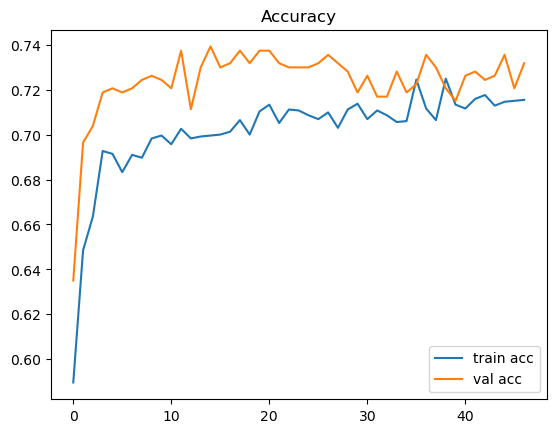

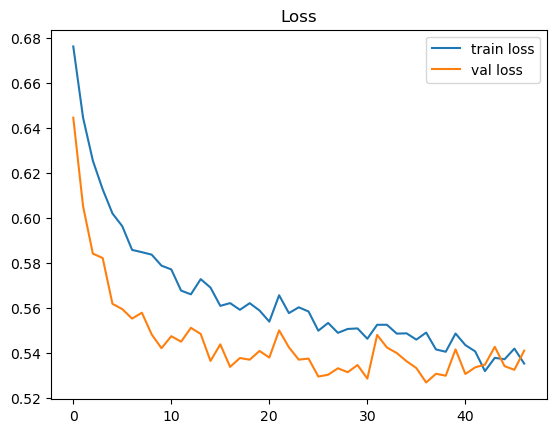

In [110]:
# Accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()


In [111]:
y_probs = model_simple.predict(X_test)
y_probs = (y_probs > 0.5).astype("int")

print(classification_report(y_test, y_probs))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.71      0.82      0.76       397
           1       0.73      0.58      0.65       320

    accuracy                           0.72       717
   macro avg       0.72      0.70      0.70       717
weighted avg       0.72      0.72      0.71       717



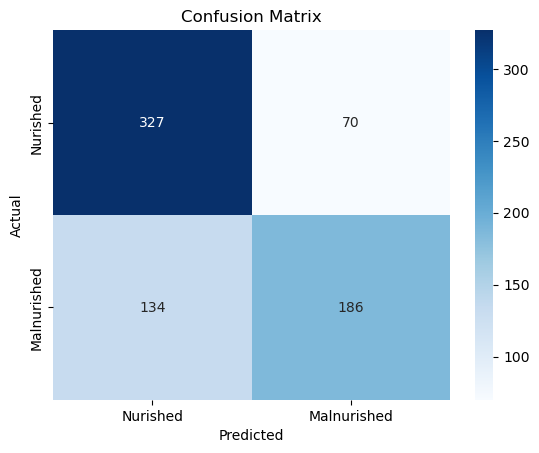

In [112]:
cm = confusion_matrix(y_test, y_probs)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [113]:
# Use model.predict() and flatten to 1D
y_probas = model_simple.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Average Precision: 0.776117806807674


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


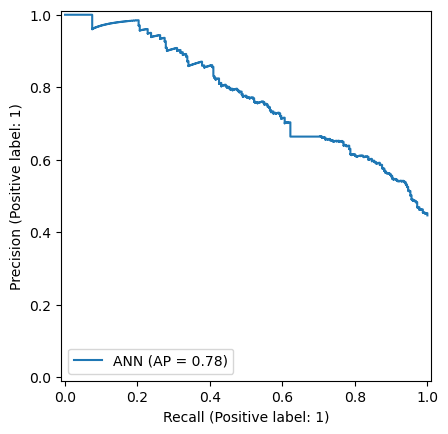

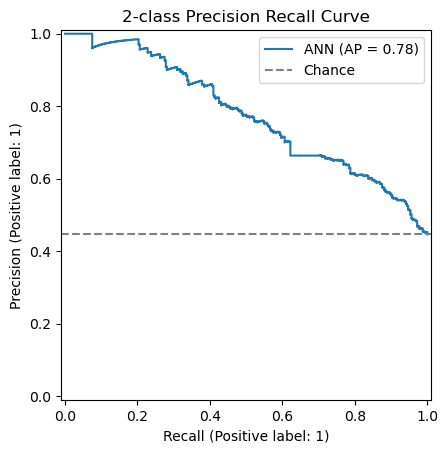

In [114]:
# Get predicted probabilities
y_probas = model_simple.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()